In [1]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

from pymargins import GComputation, pairwise  # 0.4.0: Margins -> GComputation
from pymargins.adapters import LifelinesCoxPHAdapter

df = load_rossi()
print(df.head())
print(f"\nn = {len(df)}, events = {df['arrest'].sum()}, "
      f"max follow-up = {df['week'].max()} weeks")

   week  arrest  fin  age  race  wexp  mar  paro  prio
0    20       1    0   27     1     0    0     1     3
1    17       1    0   18     1     0    0     1     8
2    25       1    0   19     0     1    0     1    13
3    52       0    1   23     1     1    1     1     1
4    52       0    0   19     0     1    0     1     3

n = 432, events = 114, max follow-up = 52 weeks


In [2]:
cph = CoxPHFitter().fit(df, duration_col="week", event_col="arrest")
print(cph.summary[["coef", "exp(coef)", "se(coef)", "p"]].round(3))

            coef  exp(coef)  se(coef)      p
covariate                                   
fin       -0.379      0.684     0.191  0.047
age       -0.057      0.944     0.022  0.009
race       0.314      1.369     0.308  0.308
wexp      -0.150      0.861     0.212  0.480
mar       -0.434      0.648     0.382  0.256
paro      -0.085      0.919     0.196  0.665
prio       0.091      1.096     0.029  0.001


In [3]:
adapter = LifelinesCoxPHAdapter(cph, training_data=df)
m = GComputation(cph, adapter=adapter, at="overall", scale="log")

scen, w = pairwise("fin", [1, 0])
hr = m.contrasts(scenarios=scen, contrasts=w)
print(hr.summary())

             Graph Result (delta, level=0.95)             
       estimate  std err        z  P>|z|  [95% Conf. Int.]
----------------------------------------------------------
fin=1    0.6843   0.1914  -1.9826  0.047    0.4702, 0.9957

n = 432
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 1.301%
plan 79acfc9@1 | κ = 0.000


In [4]:
prio_levels = [0, 2, 4, 6]
k = len(prio_levels)
scenarios = (
    [{"atexog": {"fin": 1, "prio": p},
      "label": f"fin=1, prio={p}"} for p in prio_levels]
    + [{"atexog": {"fin": 0, "prio": p},
        "label": f"fin=0, prio={p}"} for p in prio_levels]
)
W = np.zeros((k, 2 * k))
for i in range(k):
    W[i, i] = +1.0
    W[i, k + i] = -1.0
het = m.contrasts(scenarios=scenarios, contrasts=W)
print(het.summary())

                Graph Result (delta, level=0.95)                
             estimate  std err        z  P>|z|  [95% Conf. Int.]
----------------------------------------------------------------
contrast[0]    0.6843   0.1914  -1.9826  0.047    0.4702, 0.9957
contrast[1]    0.6843   0.1914  -1.9826  0.047    0.4702, 0.9957
contrast[2]    0.6843   0.1914  -1.9826  0.047    0.4702, 0.9957
contrast[3]    0.6843   0.1914  -1.9826  0.047    0.4702, 0.9957

n = 432
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
Delta-vs-sim disagreement: 0.965%
plan 79acfc9@1 | κ = max 0.000


[Text(0.5, 0, 'Age at release'),
 Text(0, 0.5, 'Treatment hazard ratio (fin=1 vs fin=0)')]

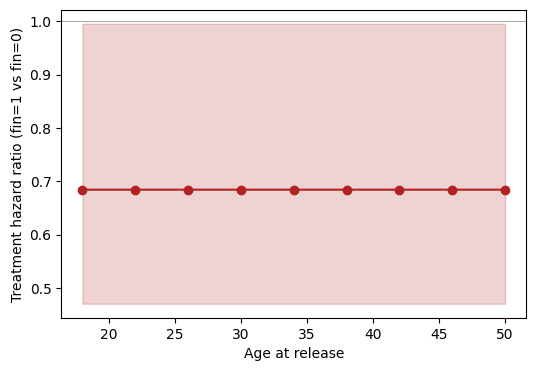

In [5]:
import matplotlib.pyplot as plt

ages = list(range(18, 51, 4))
n = len(ages)
scenarios = (
    [{"atexog": {"fin": 1, "age": a}, "label": f"fin=1, age={a}"} for a in ages]
    + [{"atexog": {"fin": 0, "age": a}, "label": f"fin=0, age={a}"} for a in ages]
)
# One contrast per age: +1 on treated row, -1 on the matching control row.
W = np.zeros((n, 2 * n))
for i in range(n):
    W[i, i] = +1.0
    W[i, n + i] = -1.0
res_age = m.contrasts(scenarios=scenarios, contrasts=W)
df_age = res_age.to_frame()
df_age["age"] = ages

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_age["age"], df_age["estimate"], "o-", color="firebrick")
ax.fill_between(
    df_age["age"], df_age["ci_lower"], df_age["ci_upper"],
    alpha=0.2, color="firebrick",
)
ax.axhline(1.0, color="grey", lw=0.5)
ax.set(xlabel="Age at release",
       ylabel="Treatment hazard ratio (fin=1 vs fin=0)")

In [6]:
m_boot = GComputation(cph, adapter=adapter, at="overall",
    method="bootstrap", B=300, seed=0, scale="log")
print(m_boot.contrasts(scenarios=scen, contrasts=w).summary())

/home/hunter/Workspace/pymargins/pymargins/estimators/_base.py:176: SoundnessWarning: [tail_count_low] Bootstrap tail count ≈ 7.5 (< 10) at level=0.95: percentile tails are poorly estimated. Increase B or use ci="se".
  self._plan, self._report, self._compiled = compile(


            Graph Result (bootstrap, level=0.95)            
       estimate  std err  statistic  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
fin=1    0.6843   0.2039    -0.3794  0.053    0.4697, 0.9944

n = 432
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
plan 8d9855d@1 | κ = 0.000


/home/hunter/Workspace/pymargins/pymargins/estimators/_base.py:176: SoundnessWarning: [tail_count_low] Bootstrap tail count ≈ 7.5 (< 10) at level=0.95: percentile tails are poorly estimated. Increase B or use ci="se".
  self._plan, self._report, self._compiled = compile(


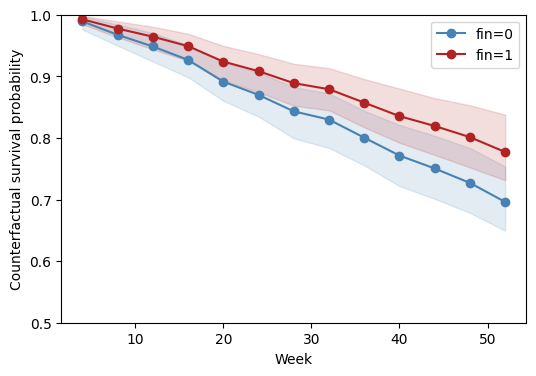

In [7]:
from pymargins.adapters import LifelinesCoxPHSurvivalAdapter

surv_adapter = LifelinesCoxPHSurvivalAdapter(cph, training_data=df)
m_surv = GComputation(
    cph, adapter=surv_adapter, at="overall",
    method="bootstrap", B=300, seed=0,
)

weeks = np.arange(4, 53, 4)
scens = (
    [{"atexog": {"fin": 1}, "prediction_time": float(t),
      "label": f"fin=1,t={t}"} for t in weeks]
    + [{"atexog": {"fin": 0}, "prediction_time": float(t),
        "label": f"fin=0,t={t}"} for t in weeks]
)
curves = m_surv.contrasts(scenarios=scens, contrasts=np.eye(len(scens)))
curve_df = curves.to_frame()
curve_df["arm"] = ["fin=1"] * len(weeks) + ["fin=0"] * len(weeks)
curve_df["week"] = list(weeks) * 2

fig, ax = plt.subplots(figsize=(6, 4))
for arm, color in [("fin=0", "steelblue"), ("fin=1", "firebrick")]:
    sub = curve_df[curve_df["arm"] == arm]
    ax.plot(sub["week"], sub["estimate"], "-o", color=color, label=arm)
    ax.fill_between(sub["week"], sub["ci_lower"], sub["ci_upper"],
                    alpha=0.15, color=color)
ax.set(xlabel="Week", ylabel="Counterfactual survival probability",
       ylim=(0.5, 1.0))
ax.legend()

[Text(0.5, 0, 'Week'), Text(0, 0.5, 'S(t | fin=1) − S(t | fin=0)')]

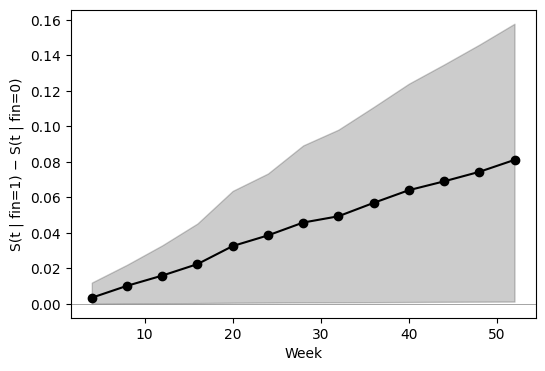

In [8]:
k = len(weeks)
W = np.zeros((k, 2 * k))
for i in range(k):
    W[i, i] = +1.0       # treated arm at week i
    W[i, k + i] = -1.0   # control arm at the same week
diff = m_surv.contrasts(scenarios=scens, contrasts=W)
diff_df = diff.to_frame()
diff_df["week"] = list(weeks)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(diff_df["week"], diff_df["estimate"], "-o", color="black")
ax.fill_between(diff_df["week"], diff_df["ci_lower"], diff_df["ci_upper"],
                alpha=0.2, color="black")
ax.axhline(0.0, color="grey", lw=0.5)
ax.set(xlabel="Week", ylabel="S(t | fin=1) − S(t | fin=0)")